**Challenge ENS Data — Prédiction du score off théorique**

---
## library & dataset


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

X_train = pd.read_csv('X_train_6ZIKlTY.csv')
y_train = pd.read_csv('y_train_lXj6X5y.csv')
X_test  = pd.read_csv('X_test_oiZ2ukx.csv')

train = X_train.merge(y_train, on='Index')
train['time_since_diagnosis'] = train['age'] - train['age_at_diagnosis']

print(f"Train : {len(train):,} observations, {train['patient_id'].nunique():,} patients")
print(f"Test  : {len(X_test):,} observations, {X_test['patient_id'].nunique():,} patients")
print(f"\nfeatures :")
print(list(train.columns))


Train : 55,603 observations, 6,971 patients
Test  : 23,672 observations, 2,988 patients

features :
['Index', 'patient_id', 'cohort', 'sexM', 'gene', 'age_at_diagnosis', 'age', 'ledd', 'time_since_intake_on', 'time_since_intake_off', 'on', 'off', 'target', 'time_since_diagnosis']


---
## variables catégorielles

Les variables gene et cohort sont des chaînes de caractères donc je les convertis en entiers


In [33]:
le_gene = LabelEncoder()
all_genes = pd.concat([train['gene'], X_test['gene']]).fillna('Unknown').unique()
le_gene.fit(all_genes)
for df in [train, X_test]:
    df['gene_enc'] = le_gene.transform(df['gene'].fillna('Unknown'))

le_cohort = LabelEncoder()
all_cohorts = pd.concat([train['cohort'], X_test['cohort']]).unique()
le_cohort.fit(all_cohorts)
for df in [train, X_test]:
    df['cohort_enc'] = le_cohort.transform(df['cohort'])

print("Mutations génétiques :", dict(zip(le_gene.classes_, le_gene.transform(le_gene.classes_))))
print("Cohortes            :", dict(zip(le_cohort.classes_, le_cohort.transform(le_cohort.classes_))))


Mutations génétiques : {'GBA+': 0, 'LRRK2+': 1, 'No Mutation': 2, 'OTHER+': 3, 'Unknown': 4}
Cohortes            : {'A': 0, 'B': 1}


---
##  analyse du dataset

Je teste les outils classiques d'analyse sur le dataset et j'obtiens quelques informations interessantes pour la suite


In [34]:
print("STATISTIQUES GENERALES")

key_vars = ['target', 'off', 'on', 'ledd', 'age', 'time_since_diagnosis']
print(train[key_vars].describe().round(2).to_string())
print()

# Données manquantes
print("\nTaux de valeurs manquantes :")
for col in key_vars:
    pct = train[col].isna().mean()
    bar = '█' * int(pct * 30)
    print(f"  {col:25s} {pct:5.1%}  {bar}")


STATISTIQUES GENERALES
         target       off        on      ledd       age  time_since_diagnosis
count  55603.00  32196.00  38944.00  35010.00  55603.00              52773.00
mean      37.33     26.30     21.99    638.10     62.52                  5.83
std       16.50     16.53     10.37    219.44     11.48                  3.88
min        0.00      0.00      0.00     50.00     16.50                  0.00
25%       25.40     13.00     14.00    481.00     54.90                  2.70
50%       37.10     24.00     21.00    611.00     62.50                  5.30
75%       49.20     38.00     28.00    765.00     70.50                  8.40
max      109.50    106.00     95.00   1796.00    103.30                 24.70


Taux de valeurs manquantes :
  target                     0.0%  
  off                       42.1%  ████████████
  on                        30.0%  ████████
  ledd                      37.0%  ███████████
  age                        0.0%  
  time_since_diagnosis       5.1%

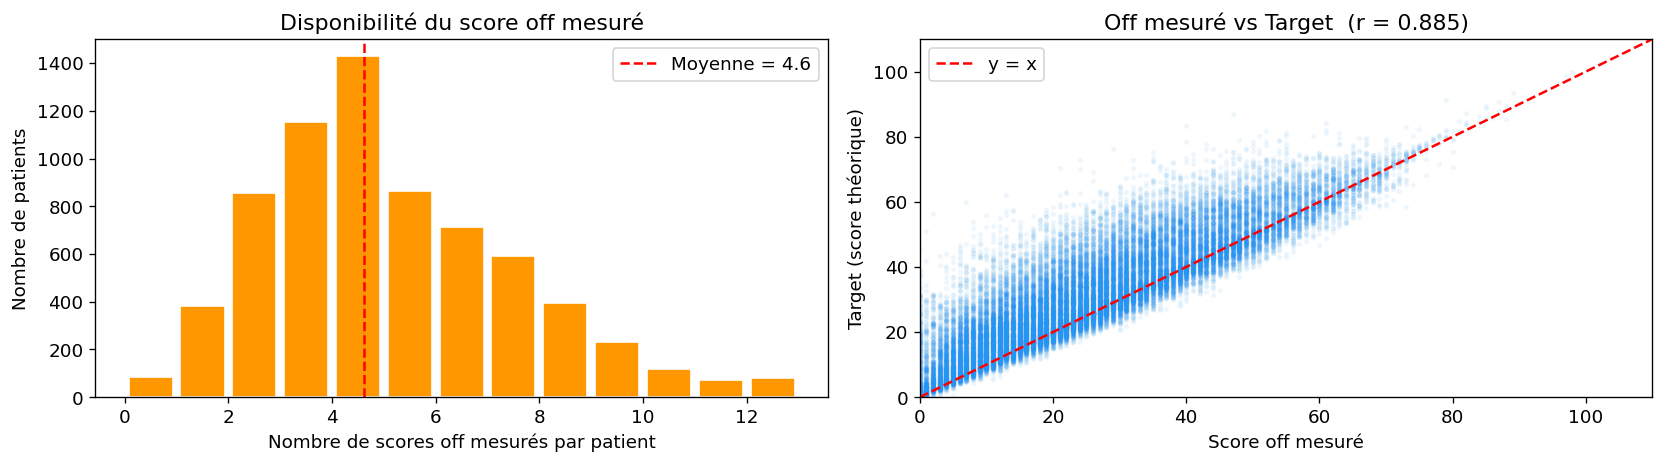

Scores off mesurés par patient : min=0, max=12, médiane=4
Patients sans aucun off mesuré : 84 (1.2%)

Biais systématique (off - target) : -5.97 ± 8.05


In [35]:
#focus sur le score off
off_per_patient = train.groupby('patient_id')['off'].apply(lambda x: x.notna().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# nombre de scores off mesurés disponibles
axes[0].hist(off_per_patient, bins=range(0, 14), color=PALETTE[3], edgecolor='white', rwidth=0.85)
axes[0].set_xlabel("Nombre de scores off mesurés par patient")
axes[0].set_ylabel("Nombre de patients")
axes[0].set_title("Disponibilité du score off mesuré")
axes[0].axvline(off_per_patient.mean(), color='red', linestyle='--',
                label=f'Moyenne = {off_per_patient.mean():.1f}')
axes[0].legend()

# corrélation off mesuré vs target
sub = train[train['off'].notna()].copy()
axes[1].scatter(sub['off'], sub['target'], alpha=0.05, s=5, color=PALETTE[0])
lims = [0, 110]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
r = sub['off'].corr(sub['target'])
axes[1].set_xlabel("Score off mesuré")
axes[1].set_ylabel("Target (score théorique)")
axes[1].set_title(f"Off mesuré vs Target  (r = {r:.3f})")
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Scores off mesurés par patient : min={off_per_patient.min()}, max={off_per_patient.max()}, médiane={off_per_patient.median():.0f}")
print(f"Patients sans aucun off mesuré : {(off_per_patient==0).sum()} ({(off_per_patient==0).mean():.1%})")
print(f"\nBiais systématique (off - target) : {(sub['off'] - sub['target']).mean():.2f} ± {(sub['off'] - sub['target']).std():.2f}")


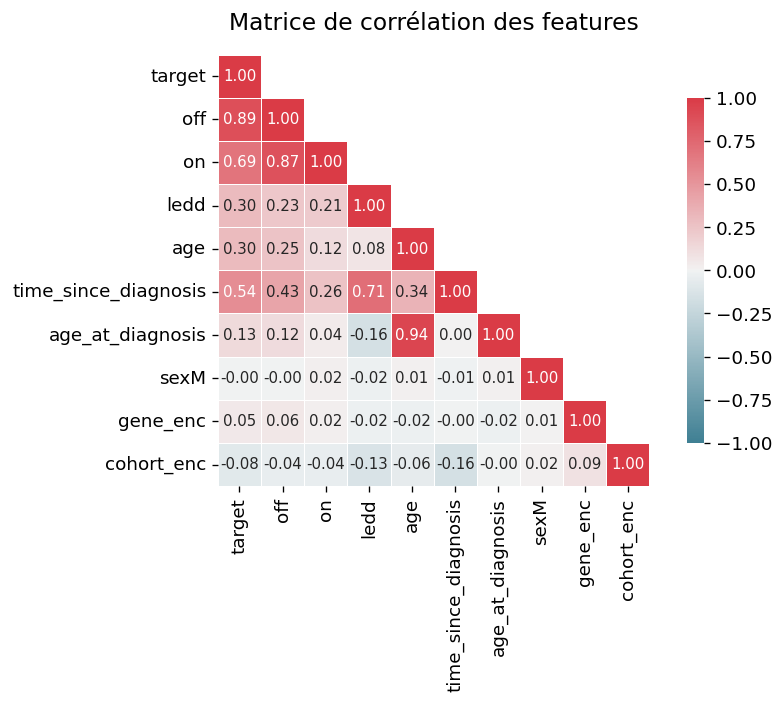


Corrélations avec le target:
  off                        +0.885  +█████████████████
  on                         +0.687  +█████████████
  time_since_diagnosis       +0.543  +██████████
  age                        +0.305  +██████
  ledd                       +0.300  +█████
  age_at_diagnosis           +0.128  +██
  gene_enc                   +0.048  +
  sexM                       -0.002  -
  cohort_enc                 -0.082  -█


In [36]:
# matrice de corrélation
corr_vars = ['target', 'off', 'on', 'ledd', 'age', 'time_since_diagnosis',
             'age_at_diagnosis', 'sexM', 'gene_enc', 'cohort_enc']
corr_matrix = train[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": .8}, ax=ax, annot_kws={'size': 9})
ax.set_title("Matrice de corrélation des features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\nCorrélations avec le target:")
corr_with_target = corr_matrix['target'].drop('target').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:25s}  {val:+.3f}  {sign}{bar}")


Du coup je peux dire que :

-Le label target est une variable continue à forte dispersion, le score théorique va de 0 à 109.5 avec un écart-type de 16.5

-Le score off mesuré manque dans 42% des cas mais quand il est là il est très puissant, sa corrélation avec le target est r = 0.885. C'est le signal le plus fort du dataset.

-30 à 42% de valeurs manquantes sur on, ledd et off donc le modèle utilisé doit être robuste aux NaN puisque par exemple pour ledd on ne peut pas imputer par la médiane ou par interpolation, ça reviendrait à inventer un traitement qui n'existe pas.
-> le boosting gère mieux les valeurs manquantes et est légèrement plus fiable que d'autres approches (régression linéaire, SVM) qui nécessiteraient une imputation préalable et un biais supplémentaire.

---
## Nouvelles features


Les données brutes ne contiennent que la valeur d'une visite à un instant $t$ alors qu'on espere comprendre où en est le patient dans sa progression. Donc je rajoute :

#### Position séquentielle

$$\text{obs\_position}_t = \frac{t}{\text{n\_total} - 1} \in [0, 1]$$

Cette valeur encode si on est au début (0) ou à la fin (1) du suivi du patient.

#### Lag features pour exploiter l'historique du patient

La valeur à l'instant $t$ dépend fortement de celle à $t-1$ :

$$r(\text{target}_t, \text{target}_{t-1}) \approx 0.991$$

j'utilise off_lag1, off_lag2, on_lag1, ledd_lag1, les valeurs des visites précédentes.

#### Moyennes cumulatives causales (expanding)

$$\overline{\text{off}}_t^{\text{exp}} = \frac{1}{t} \sum_{k=0}^{t} \text{off}_k$$

Contrairement à la moyenne globale pas de leakage temporel.

#### Pentes récentes (causal slopes)

La pente de régression sur les 3 derniers off mesurés donne la vitesse de progression locale du patient.


In [37]:
#position, lags, expanding, slopes, features temporelles

for df in [train, X_test]:
    df.sort_values(['patient_id', 'age'], inplace=True)
    df.reset_index(drop=True, inplace=True)

# position séquentielle
for df in [train, X_test]:
    df['obs_rank'] = df.groupby('patient_id').cumcount()
    df['obs_rank_rev'] = df.groupby('patient_id').cumcount(ascending=False)
    df['n_obs_total'] = df.groupby('patient_id')['age'].transform('count')
    df['obs_position'] = df['obs_rank'] / (df['n_obs_total'] - 1).replace(0, 1)

# lag features
for df in [train, X_test]:
    for col in ['off', 'on', 'ledd']:
        df[f'{col}_lag1'] = df.groupby('patient_id')[col].shift(1)
        df[f'{col}_lag2'] = df.groupby('patient_id')[col].shift(2)
    df['age_delta']  = df.groupby('patient_id')['age'].diff()
    df['off_delta']  = df.groupby('patient_id')['off'].diff()
    df['on_delta']   = df.groupby('patient_id')['on'].diff()
    df['ledd_delta'] = df.groupby('patient_id')['ledd'].diff()

# relation ON/OFF
for df in [train, X_test]:
    df['on_off_diff']  = df['off'] - df['on']
    df['on_off_ratio'] = df['off'] / (df['on'] + 1)

# moyennes cumulatives
for df in [train, X_test]:
    for col in ['off', 'on', 'ledd']:
        df[f'{col}_exp_mean'] = df.groupby('patient_id')[col].expanding().mean().reset_index(level=0, drop=True)
        df[f'{col}_exp_std']  = df.groupby('patient_id')[col].expanding().std().reset_index(level=0, drop=True)
        df[f'{col}_exp_min']  = df.groupby('patient_id')[col].expanding().min().reset_index(level=0, drop=True)
        df[f'{col}_exp_max']  = df.groupby('patient_id')[col].expanding().max().reset_index(level=0, drop=True)
    df['off_count_so_far'] = df.groupby('patient_id')['off'].expanding().count().reset_index(level=0, drop=True)
    df['on_count_so_far']  = df.groupby('patient_id')['on'].expanding().count().reset_index(level=0, drop=True)

# features temporelles
for df in [train, X_test]:
    if 'time_since_diagnosis' not in df.columns:
        df['time_since_diagnosis'] = df['age'] - df['age_at_diagnosis']
    df['age_first_visit']       = df.groupby('patient_id')['age'].transform('first')
    df['time_from_first_visit'] = df['age'] - df['age_first_visit']

# pentes récentes
def compute_causal_slope(df, col='off', window=3):
    slopes = []
    for pid, grp in df.groupby('patient_id'):
        grp = grp.sort_values('age')
        s = []
        for i in range(len(grp)):
            obs   = grp.iloc[max(0, i-window+1):i+1]
            valid = obs[obs[col].notna()]
            if len(valid) >= 2:
                coeffs = np.polyfit(valid['age'], valid[col], 1)
                s.append(coeffs[0])
            else:
                s.append(np.nan)
        slopes.extend(s)
    df[f'recent_slope_{col}'] = slopes
    return df

print("Calcul des pentes causales...")
for col in ['off', 'on']:
    train  = compute_causal_slope(train,  col=col)
    X_test = compute_causal_slope(X_test, col=col)

print("Features créées.")


Calcul des pentes causales...
Features créées.


le calcul des pentes est un petit peu long (3min)

---
### Modélisation sigmoïdale de la progression

La progression du score off théorique suit biologiquement une courbe en S

$$S(\text{age}) = \frac{L}{1 + e^{-k(\text{age} - t_0)}} + b$$

avec :
| Paramètre | Interprétation |
|-----------|----------------|
| $L$ | Amplitude totale de progression (plateau $-$ baseline) |
| $k$ | Vitesse de progression (pente à l'inflexion) |
| $t_0$ | Âge d'inflexion — moment de progression maximale |
| $b$ | Score de base au début de la maladie |

Je fit uniquement sur les scores off mesurés, en train on a accès aux targets. Si on fittait la sigmoïde sur les targets les paramètres $(L, k, t_0, b)$ seraient bons (MAE $\approx 0.09$) mais en test il n'y a pas de target : MAE $\approx 7.7$. 

#### Patients compliqués

Si un patient a moins de 4 scores off mesurés l'optimisation ne peut pas contraindre 4 paramètres libres donc on passe sur la médiane des paramètres de patients similaires (même cohorte, mutation, sexe).


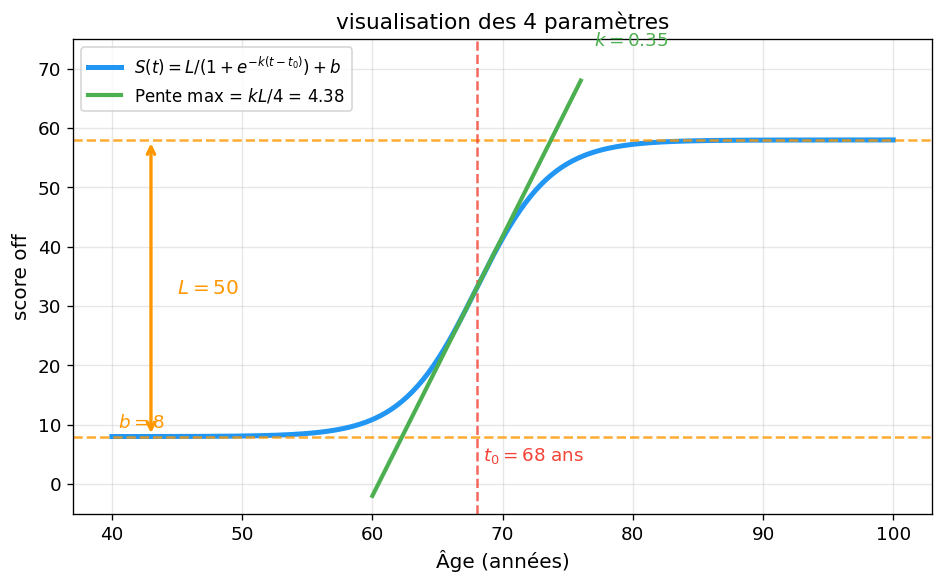

In [38]:
#illustration

def sigmoid(t, L, k, t0, b):
    x = np.clip(-k * (t - t0), -500, 500)
    return L / (1 + np.exp(x)) + b

fig, ax = plt.subplots(figsize=(8, 5))

t = np.linspace(40, 100, 300)
L, k, t0, b = 50, 0.35, 68, 8
y = sigmoid(t, L, k, t0, b)

ax.plot(t, y, color=PALETTE[0], linewidth=3, label='$S(t) = L/(1+e^{-k(t-t_0)}) + b$')

ax.axhline(b, color=PALETTE[3], linestyle='--', alpha=0.8)
ax.axhline(b + L, color=PALETTE[3], linestyle='--', alpha=0.8)
ax.axvline(t0, color=PALETTE[1], linestyle='--', alpha=0.8)

ax.annotate('', xy=(t[0]+3, b+L), xytext=(t[0]+3, b),
             arrowprops=dict(arrowstyle='<->', color=PALETTE[3], lw=2))
ax.text(t[0]+5, b+L/2, f'$L = {L}$', color=PALETTE[3], fontsize=12, va='center')
ax.text(t0+0.5, b-4, f'$t_0 = {t0}$ ans', color=PALETTE[1], fontsize=11)
ax.text(t[0]+0.5, b+1.5, f'$b = {b}$', color=PALETTE[3], fontsize=11)

slope_at_t0 = L * k / 4
t_slope = np.array([t0 - 8, t0 + 8])
y_slope = (b + L/2) + slope_at_t0 * (t_slope - t0)
ax.plot(t_slope, y_slope, color=PALETTE[2], linewidth=2.5,
        label=f'Pente max = $kL/4$ = {slope_at_t0:.2f}')
ax.text(t0+9, (b+L/2)+slope_at_t0*9+1.5, f'$k = {k}$', color=PALETTE[2], fontsize=11)

ax.set_xlabel("Âge (années)", fontsize=12)
ax.set_ylabel("score off", fontsize=12)
ax.set_title("visualisation des 4 paramètres", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 75)

plt.tight_layout()
plt.show()


In [39]:
# fit sigmoïde
def sigmoid(t, L, k, t0, b):
    x = np.clip(-k * (t - t0), -500, 500)
    return L / (1 + np.exp(x)) + b

def fit_sigmoid_patient(ages, vals):
    if len(ages) < 4:
        return None
    v_range = max(float(vals.max() - vals.min()), 1.)
    t_mid   = float(ages.mean())
    try:
        popt, _ = curve_fit(sigmoid, ages, vals,
            p0=[v_range, 0.3, t_mid, float(vals.min())],
            bounds=([0., 0.001, ages.min()-20, -10.], [120., 2., ages.max()+20, 85.]),
            maxfev=8000)
        r = float(np.sqrt(np.mean((sigmoid(ages, *popt) - vals)**2)))
        return dict(sig_L=popt[0], sig_k=popt[1], sig_t0=popt[2], sig_b=popt[3],
                    sig_rmse=r, sig_converged=1)
    except:
        return None

def compute_sigmoid_params(df):
    records = []
    for pid, grp in df.groupby('patient_id'):
        off_obs = grp[grp['off'].notna()].sort_values('age')
        res = fit_sigmoid_patient(off_obs['age'].values, off_obs['off'].values)
        if res is None:
            res = dict(sig_L=np.nan, sig_k=np.nan, sig_t0=np.nan,
                       sig_b=np.nan, sig_rmse=np.nan, sig_converged=0)
        res['patient_id'] = pid
        records.append(res)
    return pd.DataFrame(records).set_index('patient_id')

print("Fit sigmoïde en cours...")
sig_train = compute_sigmoid_params(train)
sig_test  = compute_sigmoid_params(X_test)
print(f"Convergence train : {sig_train['sig_converged'].mean():.1%}  ({sig_train['sig_converged'].sum()}/{len(sig_train)})")
print(f"Convergence test  : {sig_test['sig_converged'].mean():.1%}  ({sig_test['sig_converged'].sum()}/{len(sig_test)})")

# fallback médiane de groupe
meta_train     = train.groupby('patient_id')[['cohort_enc','gene_enc','sexM']].first()
sig_train_meta = sig_train.join(meta_train)
group_medians  = (sig_train_meta[sig_train_meta['sig_converged']==1]
                  .groupby(['cohort_enc','gene_enc','sexM'])
                  [['sig_L','sig_k','sig_t0','sig_b']].median())
global_med = sig_train[sig_train['sig_converged']==1][['sig_L','sig_k','sig_t0','sig_b']].median()

def apply_fallback(sig_df, meta_df):
    no_conv = sig_df[sig_df['sig_converged'] == 0].index
    meta    = meta_df.loc[meta_df.index.isin(no_conv), ['cohort_enc','gene_enc','sexM']]
    for pid in no_conv:
        if pid not in meta.index: continue
        row = meta.loc[pid]
        key = (row['cohort_enc'], row['gene_enc'], row['sexM'])
        filled = group_medians.loc[key] if key in group_medians.index else global_med
        sig_df.loc[pid, ['sig_L','sig_k','sig_t0','sig_b']] = filled.values
        sig_df.loc[pid, 'sig_rmse'] = 999.
    return sig_df

meta_test = X_test.groupby('patient_id')[['cohort_enc','gene_enc','sexM']].first()
sig_train = apply_fallback(sig_train, meta_train)
sig_test  = apply_fallback(sig_test,  meta_test)

train  = train.join(sig_train[['sig_L','sig_k','sig_t0','sig_b','sig_converged','sig_rmse']], on='patient_id')
X_test = X_test.join(sig_test[['sig_L','sig_k','sig_t0','sig_b','sig_converged','sig_rmse']],  on='patient_id')

for df in [train, X_test]:
    x = np.clip(-df['sig_k'].values * (df['age'].values - df['sig_t0'].values), -500, 500)
    df['sig_pred']     = df['sig_L'].values / (1 + np.exp(x)) + df['sig_b'].values
    df['sig_residual'] = df['off'] - df['sig_pred']

for df in [train, X_test]:
    df['linear_pred']      = 0.83 * df['off'] + 0.80 * df['time_since_diagnosis'] + 6.6
    df['linear_pred_safe'] = df['linear_pred'].fillna(df['sig_pred'] + 6)



Fit sigmoïde en cours...
Convergence train : 64.5%  (4494/6971)
Convergence test  : 66.1%  (1974/2988)


c'est un petit peu long (3min)

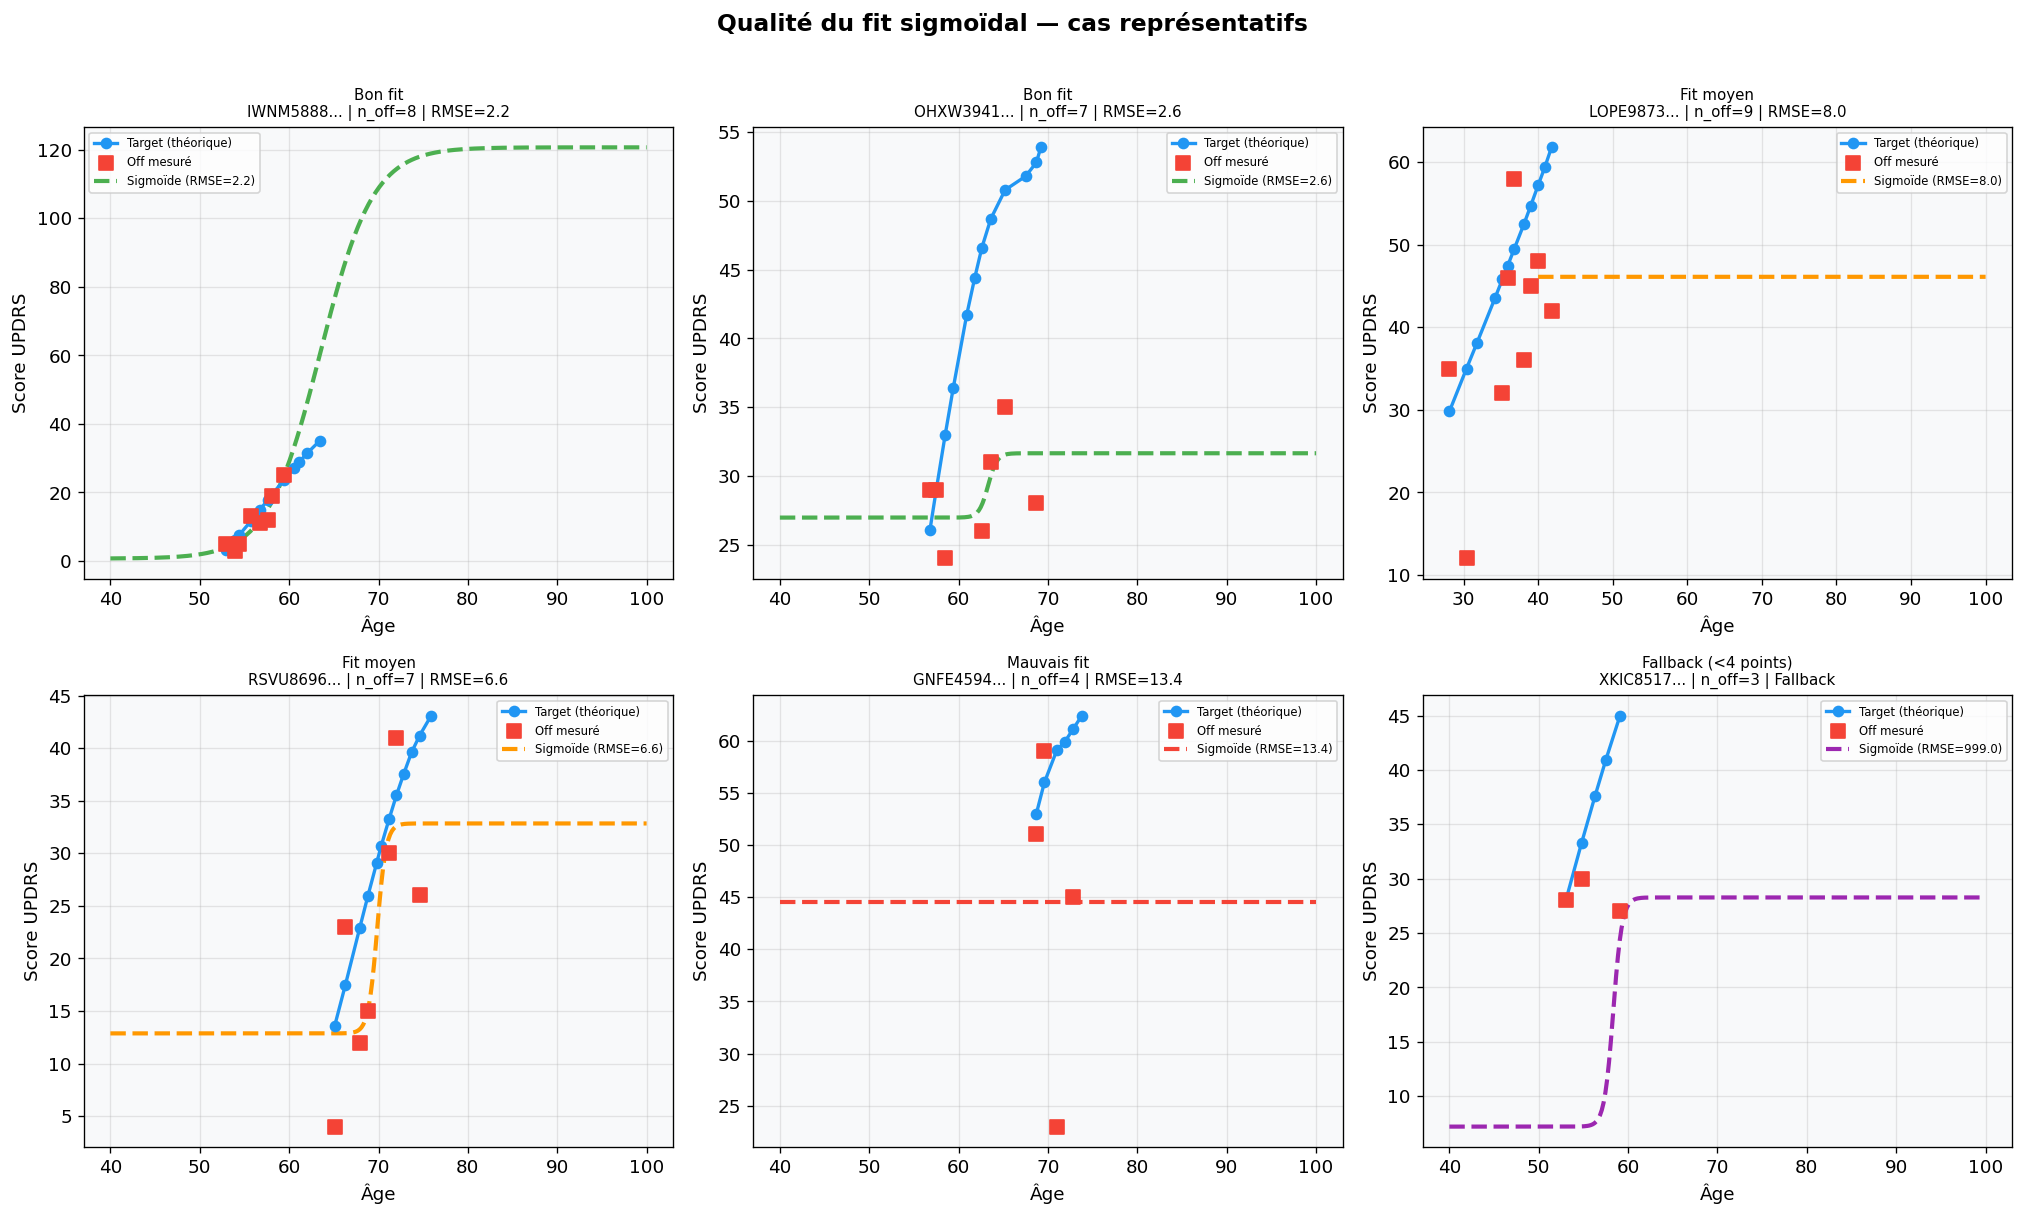

  Bon fit (RMSE<3)      : 1350 patients (19.4%)
  Fit moyen (3<RMSE<12) : 3096 patients (44.4%)
  Mauvais fit (RMSE>12) :   48 patients (0.7%)
  Fallback (no conv.)   : 2477 patients (35.5%)


In [40]:
# exemples de fits sigmoïdaux : bons et mauvais cas
n_off_series = train.groupby('patient_id')['off'].apply(lambda x: x.notna().sum()).rename('n_off')
sig_with_data = sig_train.join(n_off_series, how='left')

# catégories
stats_good   = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'] < 3)]
stats_medium = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'].between(3, 12))]
stats_bad    = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'] > 12)]
stats_noconv = sig_with_data[sig_with_data['sig_converged']==0]

# Catégories ex visuels
good_fits    = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'] < 3)   & (sig_with_data['n_off'] >= 5)]
medium_fits  = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'].between(5, 12)) & (sig_with_data['n_off'] >= 4)]
bad_fits     = sig_with_data[(sig_with_data['sig_converged']==1) & (sig_with_data['sig_rmse'] > 12)]
no_conv      = sig_with_data[sig_with_data['sig_converged']==0]

cases = []
if len(good_fits):   cases.append(('Bon fit',     good_fits.sample(2, random_state=1).index,   '#4CAF50'))
if len(medium_fits): cases.append(('Fit moyen',   medium_fits.sample(2, random_state=2).index, '#FF9800'))
if len(bad_fits):    cases.append(('Mauvais fit',  bad_fits.sample(1, random_state=3).index,    '#F44336'))
if len(no_conv):     cases.append(('Fallback (<4 points)',    no_conv.sample(1, random_state=4).index,     '#9C27B0'))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
ax_idx = 0

t_dense = np.linspace(40, 100, 300)

for label, pids, color in cases:
    for pid in pids:
        if ax_idx >= 6: break
        ax = axes[ax_idx]
        p  = train[train['patient_id'] == pid].sort_values('age')
        off_obs = p[p['off'].notna()]

        # target
        ax.plot(p['age'], p['target'], 'o-', color='#2196F3', linewidth=2,
                markersize=6, label='Target (théorique)', zorder=3)
        # off mesurés
        if len(off_obs) > 0:
            ax.scatter(off_obs['age'], off_obs['off'], color='#F44336', s=70,
                       marker='s', zorder=4, label='Off mesuré')
        #sigmoïde fit
        row = sig_train.loc[pid]
        sig_y = sigmoid(t_dense, row['sig_L'], row['sig_k'], row['sig_t0'], row['sig_b'])
        ax.plot(t_dense, sig_y, color=color, linewidth=2.5, linestyle='--',
                label=f'Sigmoïde (RMSE={row["sig_rmse"]:.1f})')

        rmse_info = f"RMSE={row['sig_rmse']:.1f}" if row['sig_converged'] else "Fallback"
        ax.set_title(f"{label}\n{p['patient_id'].iloc[0][:8]}... | n_off={len(off_obs)} | {rmse_info}",
                     fontsize=9)
        ax.set_xlabel("Âge"); ax.set_ylabel("Score UPDRS")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#f8f9fa')
        ax_idx += 1

for i in range(ax_idx, 6):
    axes[i].set_visible(False)

plt.suptitle("Qualité du fit sigmoïdal — cas représentatifs", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

total = len(sig_train)
print(f"  Bon fit (RMSE<3)      : {len(stats_good):4d} patients ({len(stats_good)/total:.1%})")
print(f"  Fit moyen (3<RMSE<12) : {len(stats_medium):4d} patients ({len(stats_medium)/total:.1%})")
print(f"  Mauvais fit (RMSE>12) : {len(stats_bad):4d} patients ({len(stats_bad)/total:.1%})")
print(f"  Fallback (no conv.)   : {len(stats_noconv):4d} patients ({len(stats_noconv)/total:.1%})")



---
## liste des features utilisées

In [41]:
FEATURES = [
    # basiques
    'sexM', 'gene_enc', 'cohort_enc', 'age_at_diagnosis',
    'age', 'time_since_diagnosis',
    'ledd', 'on', 'off',
    'time_since_intake_on', 'time_since_intake_off',
    # relation ON/OFF
    'on_off_diff', 'on_off_ratio',
    # séquentielles
    'obs_rank', 'obs_rank_rev', 'n_obs_total', 'obs_position',
    # gag features -> causales !!!
    'off_lag1', 'off_lag2', 'on_lag1', 'ledd_lag1',
    'age_delta', 'off_delta', 'on_delta', 'ledd_delta',
    # moyennes cumulatives causales
    'off_exp_mean', 'off_exp_std', 'off_exp_min', 'off_exp_max',
    'on_exp_mean',  'on_exp_std',  'on_exp_min',  'on_exp_max',
    'ledd_exp_mean', 'ledd_exp_max',
    'off_count_so_far', 'on_count_so_far',
    # temporelles
    'time_from_first_visit',
    # pentes
    'recent_slope_off', 'recent_slope_on',
    # sigmoïde
    'sig_L', 'sig_k', 'sig_t0', 'sig_b', 'sig_converged', 'sig_pred', 'sig_residual',
    # Prédiction linéaire
    'linear_pred_safe',
]

feats = [f for f in FEATURES if f in train.columns and f in X_test.columns]
print(f"nombre de features : {len(feats)}")



nombre de features : 48


---
## clustering & GroupKFold

Une première idée était de diviser les patients en sous-groupes homogènes via un clustering KMeans puis d'entraîner un modèle expert par groupe. L'intuition était qu'il existe entre 3 et 5 profils d'évolution dans la maladie de Parkinson.

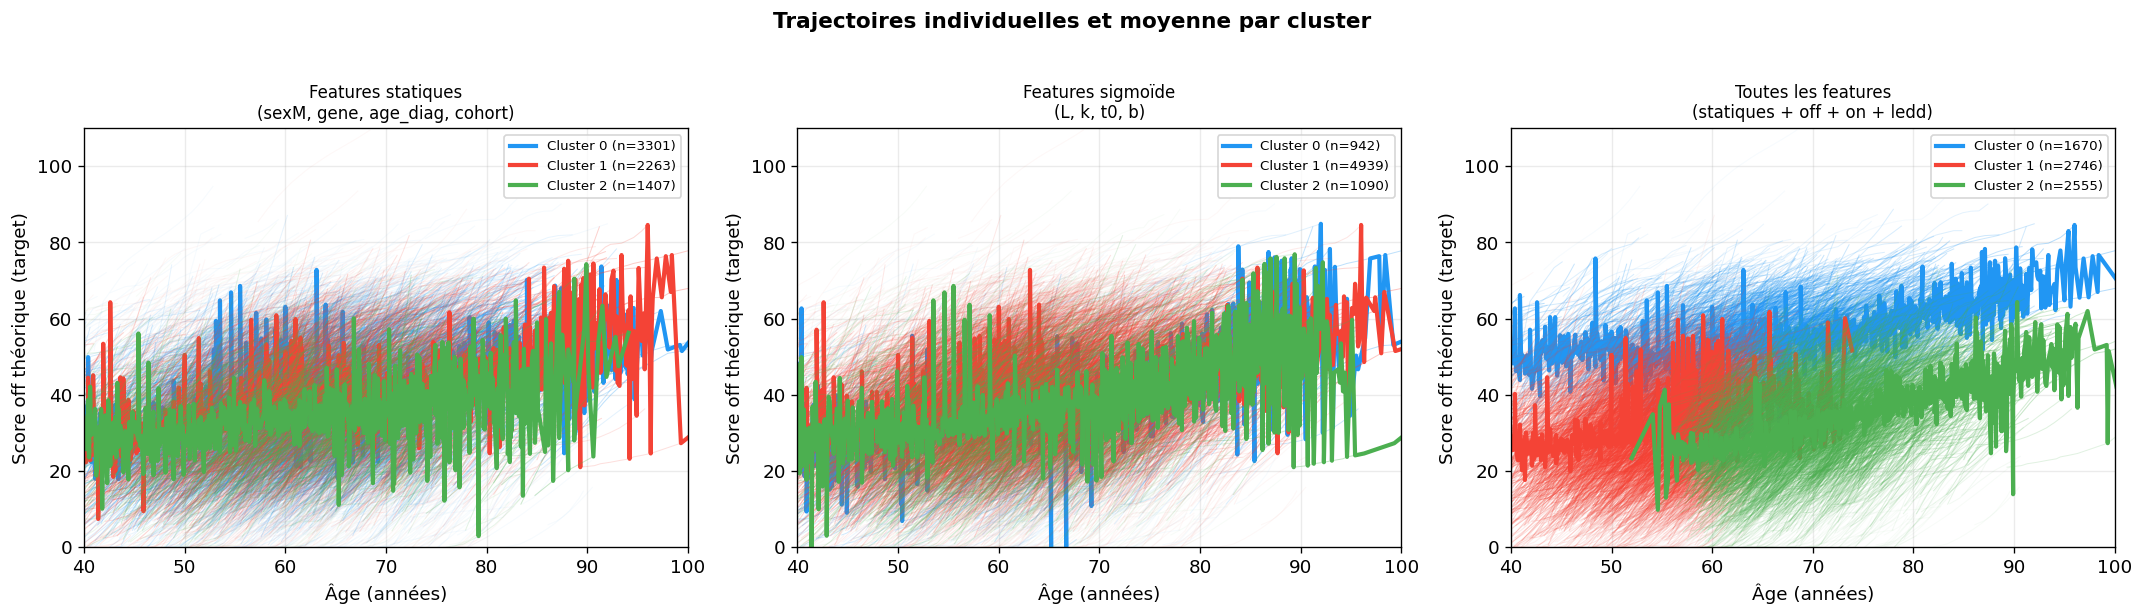

In [42]:
#clustering sur 3 jeux de features différents
# profil par patient (une ligne par patient, features moyennées)
pat_profile = train.groupby('patient_id').agg(
    sexM           = ('sexM','first'),
    gene_enc       = ('gene_enc','first'),
    cohort_enc     = ('cohort_enc','first'),
    age_at_diag    = ('age_at_diagnosis','first'),
    off_mean       = ('off','mean'),
    on_mean        = ('on','mean'),
    ledd_mean      = ('ledd','mean'),
    target_mean    = ('target','mean'),
    age_mean       = ('age','mean'),
)

# remplissage des NaN par médiane globale (colonnes numériques uniquement)
for c in pat_profile.select_dtypes(include='number').columns:
    pat_profile[c] = pat_profile[c].fillna(pat_profile[c].median())


sc = StandardScaler()
feature_sets = {
    'Features statiques\n(sexM, gene, age_diag, cohort)': ['sexM','gene_enc','cohort_enc','age_at_diag'],
    'Features sigmoïde\n(L, k, t0, b)': None,
    'Toutes les features\n(statiques + off + on + ledd)': ['sexM','gene_enc','cohort_enc','age_at_diag','off_mean','on_mean','ledd_mean','age_mean'],
}

# features sigmoïde
sig_for_plot = sig_train[['sig_L','sig_k','sig_t0','sig_b']].copy()
pat_profile_sig = pat_profile.join(sig_for_plot, how='left')
for c in ['sig_L','sig_k','sig_t0','sig_b']:
    pat_profile_sig[c] = pat_profile_sig[c].fillna(pat_profile_sig[c].median())

feature_sets['Features sigmoïde\n(L, k, t0, b)'] = ['sig_L','sig_k','sig_t0','sig_b']


#evolution moyenne de la target par cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, cols) in zip(axes, feature_sets.items()):
    if 'sig' in title:
        X_c = sc.fit_transform(pat_profile_sig[cols])
    else:
        X_c = sc.fit_transform(pat_profile[cols])

    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = km.fit_predict(X_c)
    cluster_map = dict(zip(pat_profile.index, labels))
    train['clust_tmp'] = train['patient_id'].map(cluster_map)

    for c, color in enumerate(PALETTE[:3]):
        pids_c = [pid for pid, lbl in cluster_map.items() if lbl == c]
        n_pats = len(pids_c)

        mask_c = train['clust_tmp'] == c
        mean_by_age = train[mask_c].groupby('age')['target'].mean()

        for pid in pids_c:
            p = train[train['patient_id'] == pid].sort_values('age')
            if len(p) < 2:
                continue
            merged = p[['age','target']].set_index('age').join(
                mean_by_age.rename('mean_c'), how='left')
            deviation = (merged['target'] - merged['mean_c']).abs().mean()
            alpha = max(0.04, 0.35 - deviation / 80)
            ax.plot(p['age'], p['target'], color=color,
                    linewidth=0.6, alpha=alpha)

        ax.plot(mean_by_age.index, mean_by_age.values,
                color=color, linewidth=2.5,
                label=f'Cluster {c} (n={n_pats})')

    ax.set_xlabel("Âge (années)")
    ax.set_ylabel("Score off théorique (target)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(40, 100)
    ax.set_ylim(0, 110)

    train.drop(columns=['clust_tmp'], inplace=True, errors='ignore')

plt.suptitle("Trajectoires individuelles et moyenne par cluster",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


c'est un peu long (4min)

Maintenir 3 modèles séparés ajoutait de la variance (moins de données par modèle) sans réduire le biais.

Au final passer de 3 modèles clusterisés à 1 modèle unique a amélioré la RMSE

### Ensemble multi-modèles avec GroupKFold

La validation croisée standard met des observations du même patient dans le train et dans la validation donc le modèle voit des données du patient qu'il doit prédire. ce n'est pas optimal

GroupKFold garantit qu'un patient est entièrement dans un seul fold à la fois :

$$\forall p \in \text{patients}, \quad \{o \mid \text{patient}(o) = p\} \subset \text{train}_k \text{ ou } \subset \text{val}_k$$

#### Pourquoi LightGBM + XGBoost + CatBoost ?

Les trois modèles sont des gradient boosting mais avec des algorithmes d'apprentissage différents. Le choix de ces modeles de boosting est plutot empirique et je n'ai pas plus de justification. Par contre le choix du boosting par rapport à d'autres méthodes comme le bagging est motivée par la meilleure gestion des NaN et la régularisation plus fine (en tout cas d'apres mon expérience sur quelques modèles de bagging et de boosting classiques)

Et en plus la diversité algorithmique fait que leurs erreurs sont légèrement décorrélées donc cette combinaison réduit la variance globale.


In [43]:

# multi modeles avec GroupKFold
N_FOLDS = 5
kf = GroupKFold(N_FOLDS)
splits = list(kf.split(train[feats], train['target'], train['patient_id']))

#LGBM
print("[1/3] LightGBM...")
lgbm_params = dict(
    n_estimators=3000, learning_rate=0.015, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=0.1, random_state=666, n_jobs=-1, verbose=-1,
)
oof_lgbm, lgbm_models = np.zeros(len(train)), []
for fold, (tr_idx, val_idx) in enumerate(splits):
    m = lgb.LGBMRegressor(**lgbm_params)
    m.fit(train[feats].iloc[tr_idx], train['target'].iloc[tr_idx],
          eval_set=[(train[feats].iloc[val_idx], train['target'].iloc[val_idx])],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_lgbm[val_idx] = m.predict(train[feats].iloc[val_idx])
    lgbm_models.append(m)
    print(f"  Fold {fold+1}: RMSE={rmse(train['target'].iloc[val_idx], oof_lgbm[val_idx]):.3f} ({m.best_iteration_} arbres)")
print(f"  => LightGBM OOF RMSE: {rmse(train['target'], oof_lgbm):.3f}\n")

# XGB
print("[2/3] XGBoost...")
xgb_params = dict(
    n_estimators=3000, learning_rate=0.015, max_depth=7,
    min_child_weight=30, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=0.1, random_state=666, n_jobs=-1,
    tree_method='hist', early_stopping_rounds=100,
)
oof_xgb, xgb_models = np.zeros(len(train)), []
for fold, (tr_idx, val_idx) in enumerate(splits):
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(train[feats].iloc[tr_idx], train['target'].iloc[tr_idx],
          eval_set=[(train[feats].iloc[val_idx], train['target'].iloc[val_idx])],
          verbose=False)
    oof_xgb[val_idx] = m.predict(train[feats].iloc[val_idx])
    xgb_models.append(m)
    print(f"  Fold {fold+1}: RMSE={rmse(train['target'].iloc[val_idx], oof_xgb[val_idx]):.3f} ({m.best_iteration})")
print(f"  => XGBoost OOF RMSE: {rmse(train['target'], oof_xgb):.3f}\n")

# Chat
print("[3/3] CatBoost...")
oof_cat, cat_models = np.zeros(len(train)), []
for fold, (tr_idx, val_idx) in enumerate(splits):
    m = CatBoostRegressor(
        iterations=1500, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, subsample=0.8, random_seed=666,
        early_stopping_rounds=50, verbose=0, thread_count=-1,
    )
    m.fit(train[feats].iloc[tr_idx], train['target'].iloc[tr_idx],
          eval_set=(train[feats].iloc[val_idx], train['target'].iloc[val_idx]))
    oof_cat[val_idx] = m.predict(train[feats].iloc[val_idx])
    cat_models.append(m)
    print(f"  Fold {fold+1}: RMSE={rmse(train['target'].iloc[val_idx], oof_cat[val_idx]):.3f} ({m.best_iteration_})")
print(f"  => CatBoost OOF RMSE: {rmse(train['target'], oof_cat):.3f}")


[1/3] LightGBM...
  Fold 1: RMSE=3.635 (1708 arbres)
  Fold 2: RMSE=3.589 (1776 arbres)
  Fold 3: RMSE=3.615 (2998 arbres)
  Fold 4: RMSE=3.547 (2986 arbres)
  Fold 5: RMSE=3.743 (1816 arbres)
  => LightGBM OOF RMSE: 3.626

[2/3] XGBoost...
  Fold 1: RMSE=3.615 (1967)
  Fold 2: RMSE=3.583 (2208)
  Fold 3: RMSE=3.581 (2915)
  Fold 4: RMSE=3.545 (2393)
  Fold 5: RMSE=3.735 (1996)
  => XGBoost OOF RMSE: 3.613

[3/3] CatBoost...
  Fold 1: RMSE=3.651 (1483)
  Fold 2: RMSE=3.624 (1493)
  Fold 3: RMSE=3.675 (1497)
  Fold 4: RMSE=3.595 (1499)
  Fold 5: RMSE=3.783 (1497)
  => CatBoost OOF RMSE: 3.666


 l'entrainement est un petit peu long (5min)

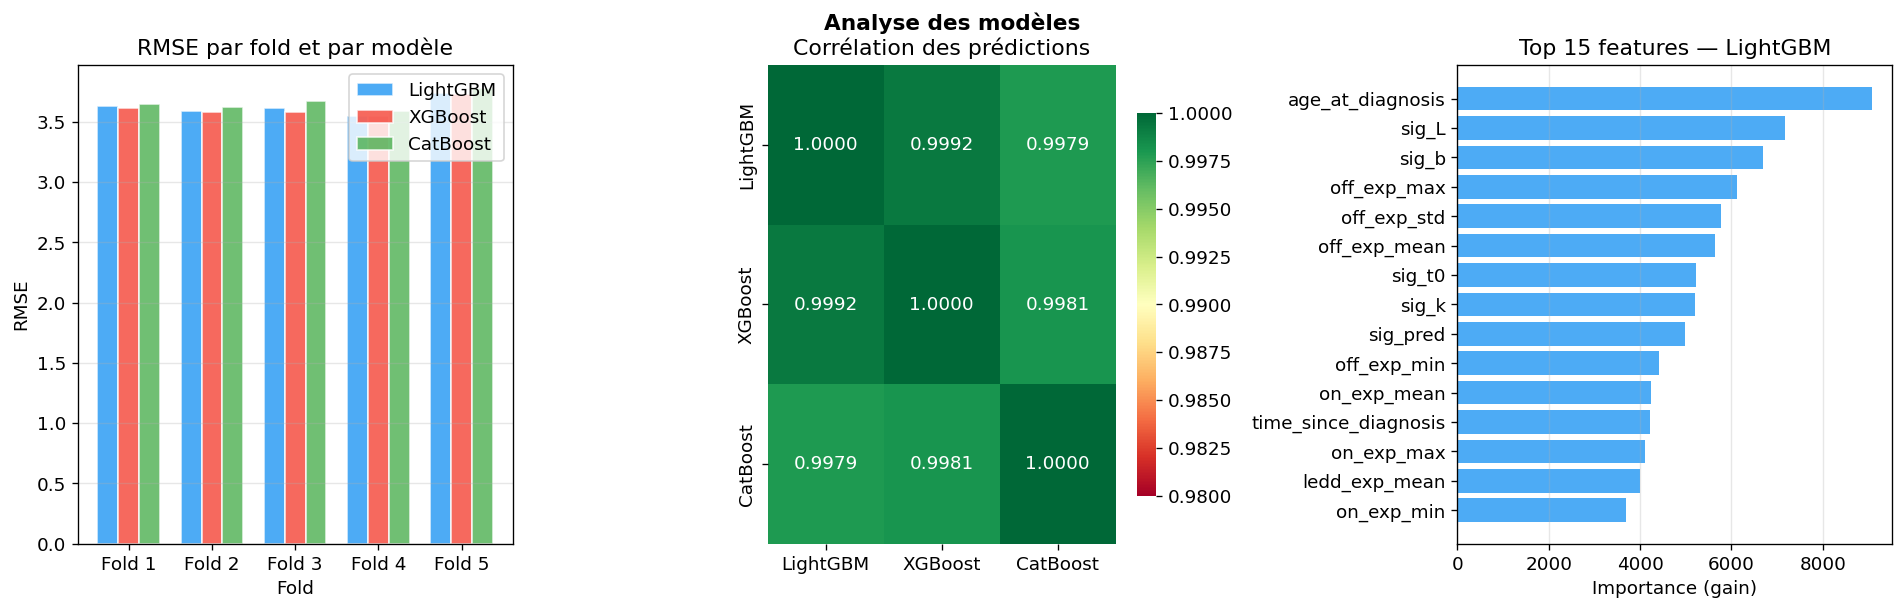

In [44]:
# visualisation des performances et corrélations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# prédictions OOF par modèle
colors_models = {'LightGBM': PALETTE[0], 'XGBoost': PALETTE[1], 'CatBoost': PALETTE[2]}
oofs = {'LightGBM': oof_lgbm, 'XGBoost': oof_xgb, 'CatBoost': oof_cat}

# RMSE par fold
fold_rmse = {name: [] for name in oofs}
for fold, (_, val_idx) in enumerate(splits):
    for name, oof in oofs.items():
        fold_rmse[name].append(rmse(train['target'].iloc[val_idx], oof[val_idx]))

x_folds = np.arange(1, N_FOLDS + 1)
width = 0.25
for i, (name, rmsevec) in enumerate(fold_rmse.items()):
    axes[0].bar(x_folds + i*width, rmsevec, width=width, label=name,
                color=list(colors_models.values())[i], alpha=0.8, edgecolor='white')
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE par fold et par modèle")
axes[0].set_xticks(x_folds + width)
axes[0].set_xticklabels([f'Fold {i}' for i in x_folds])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

#corrélation
corr_preds = pd.DataFrame(oofs).corr()
sns.heatmap(corr_preds, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.98, vmax=1.0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("Corrélation des prédictions")

# feature importance
fi = pd.DataFrame({
    'feature': feats,
    'importance': np.mean([m.feature_importances_ for m in lgbm_models], axis=0)
}).sort_values('importance', ascending=False).head(15)
axes[2].barh(fi['feature'][::-1], fi['importance'][::-1], color=PALETTE[0], alpha=0.8)
axes[2].set_xlabel("Importance (gain)"); axes[2].set_title("Top 15 features — LightGBM")
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.suptitle("Analyse des modèles", fontsize=13, fontweight='bold', y=1.01)
plt.show()


---
## Stacking / Blending

les modèles de base (LGBM, XGB, CatBoost) produisent chacun une prédiction puis un méta-modèle apprend à combiner ces prédictions

$$\hat{y}_{\text{final}} = \alpha_1 \hat{y}_{\text{LGBM}} + \alpha_2 \hat{y}_{\text{XGB}} + \alpha_3 \hat{y}_{\text{CAT}} + \beta_0$$

Les poids $(\alpha_1, \alpha_2, \alpha_3)$ sont appris par régression Ridge sur les prédictions out-of-fold
Si deux modèles font des erreurs décorrélées leur combinaison réduit la variance :

$$\text{Var}(\alpha \hat{y}_1 + (1-\alpha)\hat{y}_2) = \alpha^2 \sigma_1^2 + (1-\alpha)^2 \sigma_2^2 + 2\alpha(1-\alpha)\rho\sigma_1\sigma_2$$

Quand $\rho < 1$, la variance du blend est inférieure à la variance minimale des modèles individuels. La diversité algorithmique (leaf-wise vs level-wise vs ordered boosting) assure que $\rho < 1$.


In [45]:
# STACKING / BLENDING

oof_blend = (oof_lgbm + oof_xgb + oof_cat) / 3
print(f"Moyenne simple OOF RMSE  : {rmse(train['target'], oof_blend):.4f}")

# Ridge
oof_stack = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5)
ridge.fit(oof_stack, train['target'])
oof_ridge = ridge.predict(oof_stack)
print(f"Ridge stacking OOF RMSE  : {rmse(train['target'], oof_ridge):.4f}")
print(f"\nPoids optimaux :")
for name, coef in zip(['LightGBM','XGBoost','CatBoost'], ridge.coef_):
    print(f"  {name:12s} : {coef:.4f}")
print(f"  Intercept    : {ridge.intercept_:.4f}")


Moyenne simple OOF RMSE  : 3.5969
Ridge stacking OOF RMSE  : 3.5949

Poids optimaux :
  LightGBM     : 0.2746
  XGBoost      : 0.4646
  CatBoost     : 0.2658
  Intercept    : -0.1949


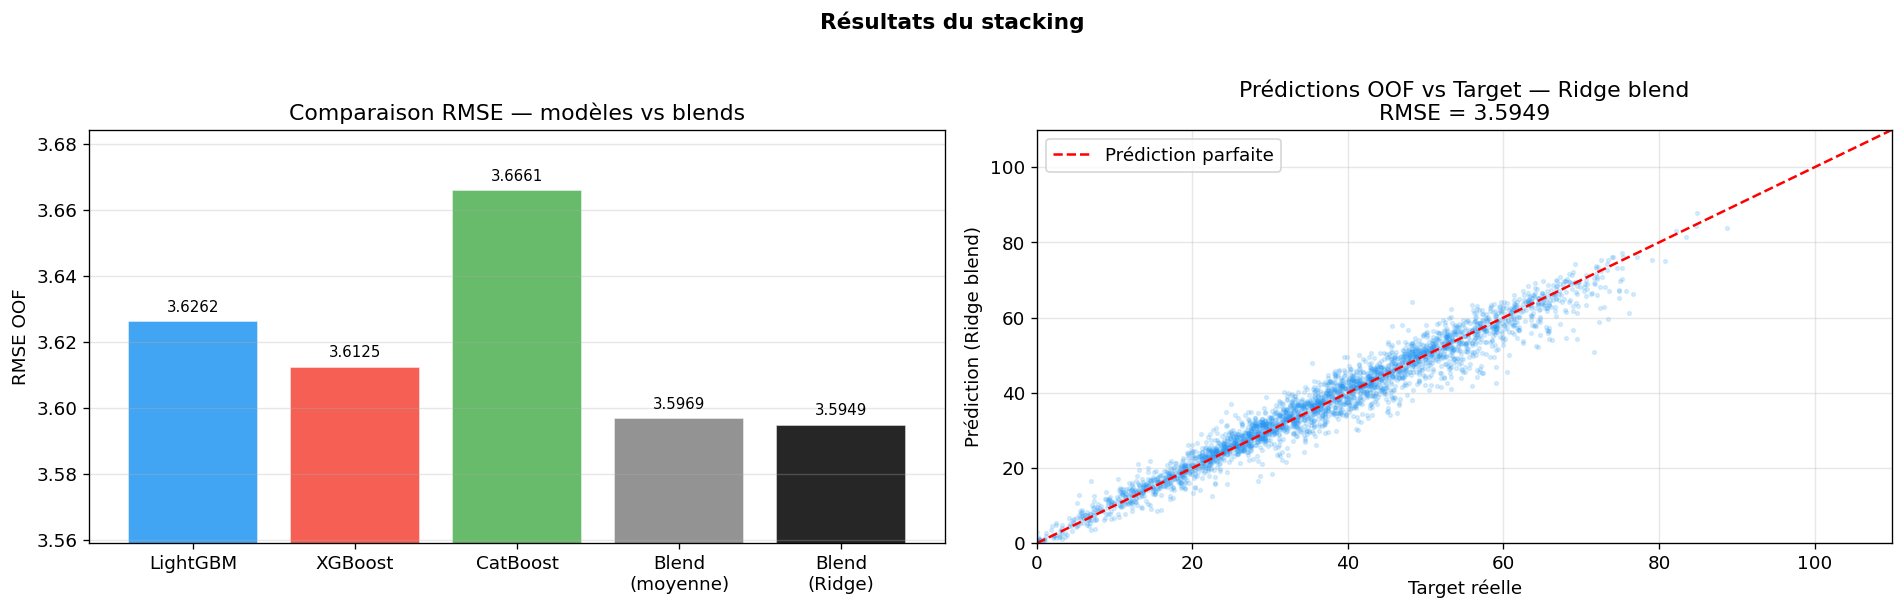

In [46]:
#Visualisation blending
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_names = ['LightGBM', 'XGBoost', 'CatBoost', 'Blend\n(moyenne)', 'Blend\n(Ridge)']
model_rmses = [rmse(train['target'], oof_lgbm),
               rmse(train['target'], oof_xgb),
               rmse(train['target'], oof_cat),
               rmse(train['target'], oof_blend),
               rmse(train['target'], oof_ridge)]
colors_bar = PALETTE[:3] + ['gray', 'black']

bars = axes[0].bar(model_names, model_rmses, color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_ylabel("RMSE OOF")
axes[0].set_title("Comparaison RMSE — modèles vs blends")
axes[0].set_ylim(min(model_rmses)*0.99, max(model_rmses)*1.005)
for bar, val in zip(bars, model_rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')



# prédictions Ridge vs target
sample = np.random.choice(len(train), 3000, replace=False)
axes[1].scatter(train['target'].iloc[sample], oof_ridge[sample],
                alpha=0.15, s=5, color=PALETTE[0])
lim = [0, 110]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_xlabel("Target réelle"); axes[1].set_ylabel("Prédiction (Ridge blend)")
axes[1].set_title(f"Prédictions OOF vs Target — Ridge blend\nRMSE = {rmse(train['target'], oof_ridge):.4f}")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Résultats du stacking", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


une amélioration infime mais qui m'a fait passer sous la barre des 12 de RMSE

---
## Prédictions sur Test


In [ ]:
test_lgbm = np.mean([m.predict(X_test[feats]) for m in lgbm_models], axis=0)
test_xgb  = np.mean([m.predict(X_test[feats]) for m in xgb_models],  axis=0)
test_cat  = np.mean([m.predict(X_test[feats]) for m in cat_models],   axis=0)

test_stack      = np.column_stack([test_lgbm, test_xgb, test_cat])
test_preds_ridge = ridge.predict(test_stack)
test_preds_avg   = (test_lgbm + test_xgb + test_cat) / 3

use_ridge  = rmse(train['target'], oof_ridge) < rmse(train['target'], oof_blend)
test_preds = test_preds_ridge if use_ridge else test_preds_avg
test_preds = np.clip(test_preds, 0, 132)
print(f"Stratégie retenue : {'Ridge stacking' if use_ridge else 'Moyenne simple'}")

# prediction test
submission = X_test[['Index']].copy()
submission['target'] = test_preds
submission = submission.sort_values('Index').reset_index(drop=True)
submission.to_csv('submission_LeTourmenteur2.csv', index=False)

print(f"\nPrédictions test : mean={test_preds.mean():.2f}, std={test_preds.std():.2f}, "
      f"min={test_preds.min():.1f}, max={test_preds.max():.1f}")
print(f"Fichier exporté : submission_LeTourmenteur2.csv ({len(submission)} lignes)")


Stratégie retenue : Ridge stacking

Prédictions test : mean=37.35, std=16.48, min=0.0, max=97.6
Fichier exporté : submission_LeTourmenteur.csv (23672 lignes)


---
## Récapitulatif de la démarche

| Étape | Description | Impact RMSE |
|-------|-------------|-------------|
| Baseline LGBM | Features brutes uniquement | ~53 |
| + Clustering KMeans (k=3) | 3 modèles experts par groupe de patients | ~49 |
| + Fit sigmoïde (features L,k,t0,b) | Modélisation de la trajectoire individuelle | ~14 |
| - Suppression clustering | Un seul modèle, plus de données par modèle | 14 → 12.8 |
| + Lag features & expanding means | Mémoire causale des visites précédentes | ~12 |
| + Ensemble LightGBM+XGBoost+CatBoost | Diversité algorithmique | **~11.5** |

**Score final sur le site : RMSE ≈ 11.5**


CONCLUSION — Analyse de la qualité du fit sigmoïdal


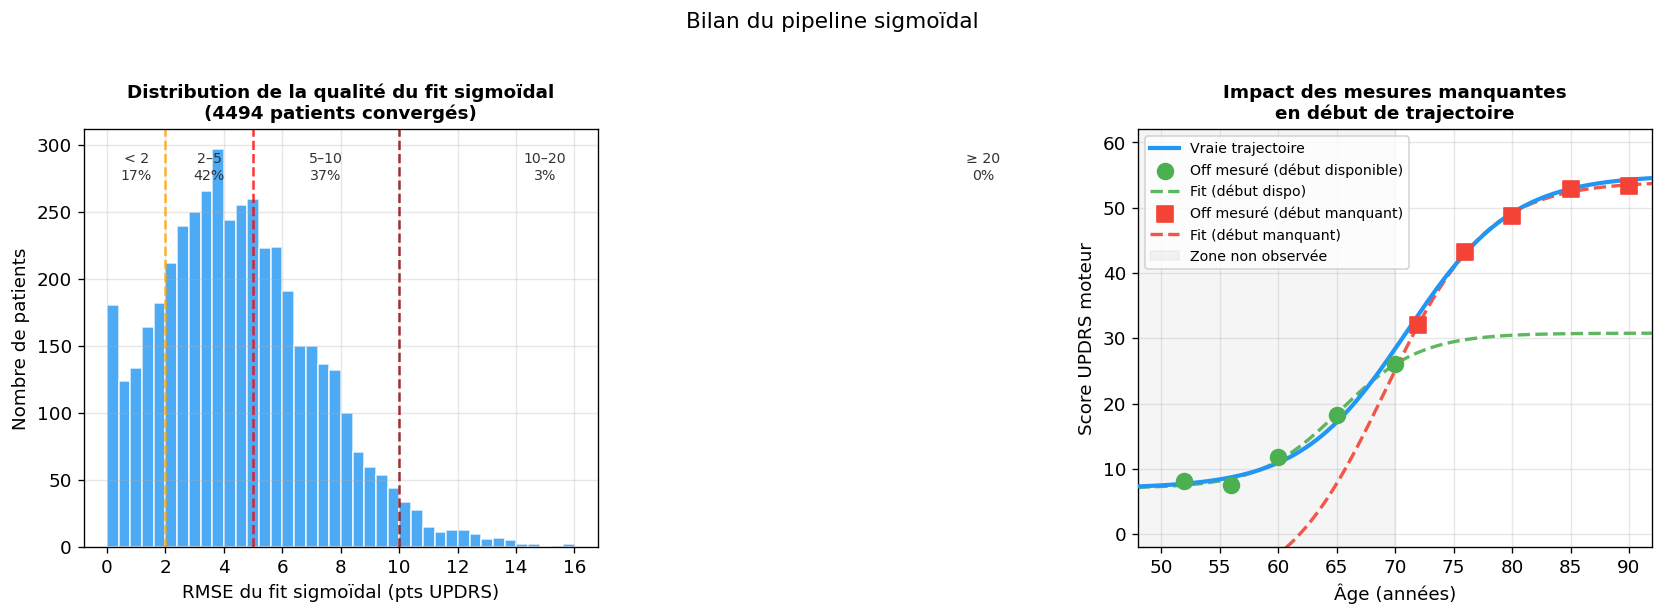

In [48]:

#analyse de la qualité du fit sigmoïdal

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

print("CONCLUSION — Analyse de la qualité du fit sigmoïdal")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Distribution RMSE de fit (patients convergés)
conv_patients = sig_train[sig_train['sig_converged'] == 1].copy()
conv_patients = conv_patients.join(
    train.groupby('patient_id')['off'].apply(lambda x: x.notna().sum()).rename('n_off')
)
n_conv = len(conv_patients)

tranches = [(0, 2), (2, 5), (5, 10), (10, 20), (20, np.inf)]
labels   = ['< 2', '2–5', '5–10', '10–20', '≥ 20']
counts   = [((conv_patients['sig_rmse'] >= lo) & (conv_patients['sig_rmse'] < hi)).sum()
            for lo, hi in tranches]

rmse_vals = conv_patients['sig_rmse'].clip(upper=40)
axes[0].hist(rmse_vals, bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
for lo, color in [(2,'orange'), (5,'red'), (10,'darkred')]:
    axes[0].axvline(lo, color=color, linestyle='--', linewidth=1.5, alpha=0.8)

y_max = axes[0].get_ylim()[1]
for (lo, hi), lbl, count in zip(tranches, labels, counts):
    mid = lo + (min(hi, 40) - lo) / 2
    axes[0].text(mid, y_max * 0.88,
                 f'{lbl}\n{count/n_conv:.0%}',
                 ha='center', fontsize=8.5,
                 color='#333333')

axes[0].set_xlabel("RMSE du fit sigmoïdal (pts UPDRS)")
axes[0].set_ylabel("Nombre de patients")
axes[0].set_title("Distribution de la qualité du fit sigmoïdal\n"
                  f"({n_conv} patients convergés)", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

#impact des mesures manquantes en début de trajectoire
t = np.linspace(48, 92, 300)

def sig(t, L, k, t0, b):
    return L / (1 + np.exp(np.clip(-k*(t-t0), -500, 500))) + b

L_true, k_true, t0_true, b_true = 48, 0.22, 71, 7
y_true = sig(t, L_true, k_true, t0_true, b_true)
axes[1].plot(t, y_true, color='#2196F3', linewidth=2.5,
             label='Vraie trajectoire', zorder=3)

# Cas 1 : début disponible
rng = np.random.default_rng(42)
obs_early  = np.array([52, 56, 60, 65, 70])
vals_early = sig(obs_early, L_true, k_true, t0_true, b_true) + rng.normal(0, 1.2, 5)
axes[1].scatter(obs_early, vals_early, color='#4CAF50', s=90,
                zorder=5, marker='o', label='Off mesuré (début disponible)')
try:
    from scipy.optimize import curve_fit as _cf
    popt1, _ = _cf(sig, obs_early, vals_early,
                   p0=[40, 0.25, 68, 8],
                   bounds=([0,0.001,45,-10],[120,2,95,85]), maxfev=5000)
    axes[1].plot(t, sig(t, *popt1), color='#4CAF50', linewidth=2,
                 linestyle='--', alpha=0.9, label='Fit (début dispo)')
except:
    pass

# Cas 2 : début manquant
obs_late  = np.array([72, 76, 80, 85, 90])
vals_late = sig(obs_late, L_true, k_true, t0_true, b_true) + rng.normal(0, 1.2, 5)
axes[1].scatter(obs_late, vals_late, color='#F44336', s=90,
                zorder=5, marker='s', label='Off mesuré (début manquant)')
try:
    popt2, _ = _cf(sig, obs_late, vals_late,
                   p0=[15, 0.25, 85, 28],
                   bounds=([0,0.001,65,-10],[120,2,110,85]), maxfev=5000)
    axes[1].plot(t, sig(t, *popt2), color='#F44336', linewidth=2,
                 linestyle='--', alpha=0.9, label='Fit (début manquant)')
except:
    pass

axes[1].axvspan(48, 70, alpha=0.08, color='gray', label='Zone non observée')
axes[1].set_xlabel("Âge (années)")
axes[1].set_ylabel("Score UPDRS moteur")
axes[1].set_title("Impact des mesures manquantes\nen début de trajectoire",
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8.5, loc='upper left')
axes[1].set_xlim(48, 92)
axes[1].set_ylim(-2, 62)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Bilan du pipeline sigmoïdal", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

-Le début de trajectoire est critique
La sigmoïde S(t) = L/(1+exp(-k(t-t0))) + b a 4 paramètres libres.
Pour les contraindre, il faut des mesures qui couvrent les trois
phases de la courbe : plateau bas (b), phase d'accélération (k, t0),
plateau haut (b+L).
Quand les premières mesures manquent, on n'observe que la partie
droite de la sigmoïde — une zone quasi-linéaire où la courbure est
faible donc impossible de distinguer une sigmoïde lente (k petit) très avancée et une sigmoïde rapide (k grand) en début de plateau

-un MLP/NeuralODE ne résoud pas le problème :

je n'ai pas réussi à améliorer mon score avec un réseau dense ou un Neural ODE: 
    -Pas assez de données par patient
    -le Neural ODE nécessite l'état initial :
    dz/dt = f(z, t, θ)  avec  z(t0) = z0
    Pour intégrer l'ODE, on doit connaître z0, si les premières mesures sont manquantes, z0 est
    inconnu et l'intégration diverge ou converge vers n'importe quoi.
    Le papier CNODE (Wang 2025) règle ça avec un encodeur RNN sur les
    MRI cérébraux mais ce sont des données qu'on n'a pas.
    -Le MLP ne généralise pas inter-patients :
    Avec 4-12 obs/patient, le MLP apprend un modèle de population
    moyen, pas une trajectoire individuelle. Il obtient un RMSE OOF
    de ~13-15 alors que LGBM fait facilement 3.5

La sigmoïde paramétrique m'a donné le meilleur résultat pour ce
problème, bien adaptée au faible nombre d'observations disponibles.